# Setup

In [2]:
# Custom
from utils.base import load_dataset
from utils.eda import check_dataset_size_and_shape, check_columns_for_nulls

In [3]:
DATASET_FILENAME = "fraudTrain.csv"
DATASET_TEST_FILENAME = "fraudTest.csv"

## Load Dataset

In [4]:

df = load_dataset(DATASET_FILENAME)
df_test = load_dataset(DATASET_TEST_FILENAME)
# df_shape: Tuple[int, int] = df.shape

## Data Splitting

In [5]:
# X = df.drop(columns=['is_fraud'])
# y = df['is_fraud']
# y_test = df_test['is_fraud']

input_features = [
  "trans_date_trans_time", "cc_num", "first", "last", "merchant", "category", "amt",
  "gender", "street", "city", "state", "zip", "lat", "long", "city_pop", "job",
  "unix_time", "merch_lat", "merch_long"
]

X = df[input_features].copy()
X_test = df_test[input_features].copy()

y = df["is_fraud"]
y_test = df_test["is_fraud"]

# Exploratory Data Analysis (EDA)

In [6]:
check_dataset_size_and_shape(df)
print("\n")
check_dataset_size_and_shape(df_test)

Number of rows: 1048575
Dataset shape: (1048575, 24)
Number of rows (alternative): 1048575


Number of rows: 555719
Dataset shape: (555719, 24)
Number of rows (alternative): 555719


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1048575 non-null  int64  
 1   trans_date_trans_time  1048575 non-null  str    
 2   cc_num                 1048575 non-null  float64
 3   merchant               1048575 non-null  str    
 4   category               1048575 non-null  str    
 5   amt                    1048575 non-null  float64
 6   first                  1048575 non-null  str    
 7   last                   1048575 non-null  str    
 8   gender                 1048575 non-null  str    
 9   street                 1048575 non-null  str    
 10  city                   1048575 non-null  str    
 11  state                  1048575 non-null  str    
 12  zip                    1048575 non-null  int64  
 13  lat                    1048575 non-null  float64
 14  long                   104857

In [8]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  str    
 2   cc_num                 555719 non-null  float64
 3   merchant               555719 non-null  str    
 4   category               555719 non-null  str    
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  str    
 7   last                   555719 non-null  str    
 8   gender                 555719 non-null  str    
 9   street                 555719 non-null  str    
 10  city                   555719 non-null  str    
 11  state                  555719 non-null  str    
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-null  float64

In [9]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,5.242870e+05,4.171565e+17,7.027910e+01,4.880159e+04,3.853336e+01,-9.022626e+01,8.905776e+04,1.344906e+09,3.853346e+01,-9.022648e+01,5.727773e-03
std,3.026977e+05,1.308811e+18,1.599518e+02,2.689804e+04,5.076852e+00,1.375858e+01,3.024351e+05,1.019700e+07,5.111233e+00,1.377093e+01,7.546503e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,2.621435e+05,1.800400e+14,9.640000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.336682e+09,3.472954e+01,-9.689864e+01,0.000000e+00
50%,5.242870e+05,3.520550e+15,4.745000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.344902e+09,3.936295e+01,-8.743923e+01,0.000000e+00
75%,7.864305e+05,4.642260e+15,8.305000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.354366e+09,4.195602e+01,-8.023228e+01,0.000000e+00
max,1.048574e+06,4.992350e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.362932e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [10]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,Data_FLAG
0,0,1/1/19 0:00,2.703190e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",3/9/88,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,TRAINING
1,1,1/1/19 0:00,6.304230e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,6/21/78,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,TRAINING
2,2,1/1/19 0:00,3.885950e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1/19/62,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,TRAINING
3,3,1/1/19 0:01,3.534090e+15,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1/12/67,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,TRAINING
4,4,1/1/19 0:03,3.755340e+14,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,3/28/86,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,TRAINING


In [11]:
df_test.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,Data_FLAG
0,0,6/21/20 12:14,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,-80.9355,333497,Mechanical engineer,3/19/68,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,TESTING
1,1,6/21/20 12:14,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,-110.4360,302,"Sales professional, IT",1/17/90,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,TESTING
2,2,6/21/20 12:14,3.598220e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,-73.5365,34496,"Librarian, public",10/21/70,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,TESTING
3,3,6/21/20 12:15,3.591920e+15,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,-80.8191,54767,Set designer,7/25/87,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,TESTING
4,4,6/21/20 12:15,3.526830e+15,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,-85.0170,1126,Furniture designer,7/6/55,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,TESTING


## Missing Data


In [12]:
check_columns_for_nulls(df)

Unnamed: 0               False
trans_date_trans_time    False
cc_num                   False
merchant                 False
category                 False
amt                      False
first                    False
last                     False
gender                   False
street                   False
city                     False
state                    False
zip                      False
lat                      False
long                     False
city_pop                 False
job                      False
dob                      False
trans_num                False
unix_time                False
merch_lat                False
merch_long               False
is_fraud                 False
Data_FLAG                False
dtype: bool


## Fraudulent Counts

In [13]:
y.value_counts()

is_fraud
0    1042569
1       6006
Name: count, dtype: int64

In [24]:
y_test.value_counts()

is_fraud
0    553574
1      2145
Name: count, dtype: int64

## Graphs

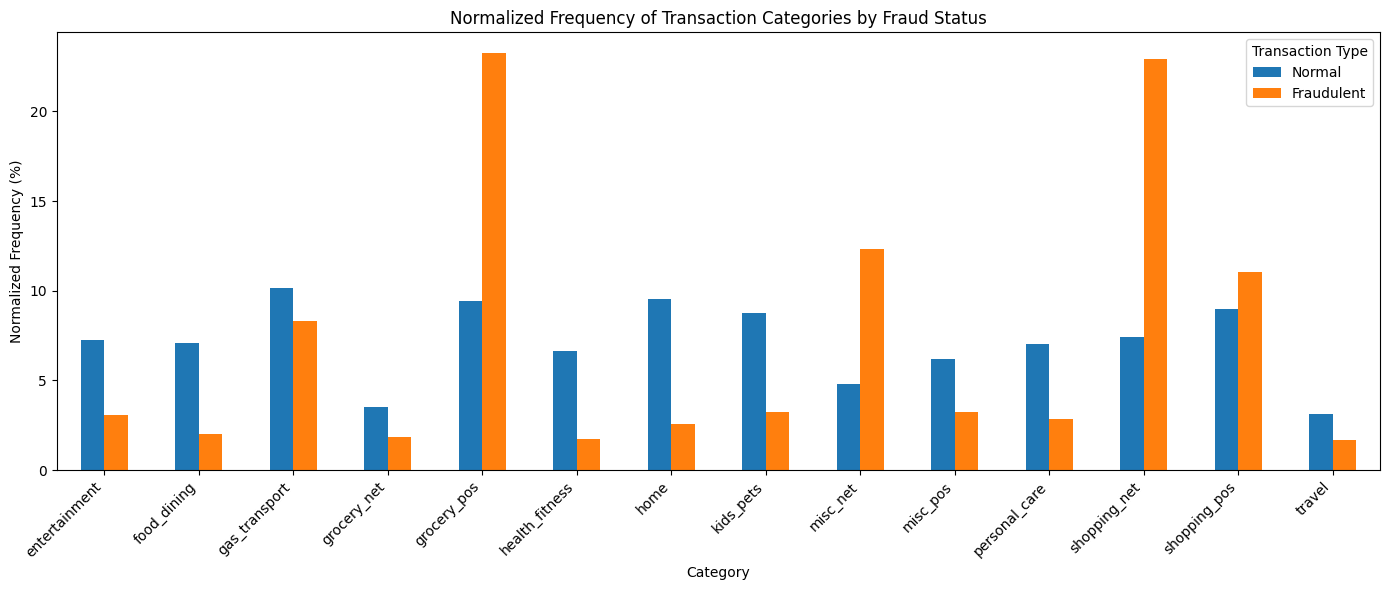

In [14]:
import matplotlib.pyplot as plt

normalized_freq = (
  df.groupby("is_fraud")["category"]
    .value_counts(normalize=True)
    .mul(100)
    .unstack(fill_value=0)
    .T
)

normalized_freq.columns = ["Normal", "Fraudulent"]

ax = normalized_freq.plot(kind="bar", figsize=(14, 6))
ax.set_title("Normalized Frequency of Transaction Categories by Fraud Status")
ax.set_xlabel("Category")
ax.set_ylabel("Normalized Frequency (%)")
ax.legend(title="Transaction Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Preprocessing

## Encode Categorical

In [15]:
from sklearn.preprocessing import OrdinalEncoder

string_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()

enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X[string_cols] = enc.fit_transform(X[string_cols])
X_test[string_cols] = enc.transform(X_test[string_cols])

In [16]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 19 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1048575 non-null  float64
 1   cc_num                 1048575 non-null  float64
 2   first                  1048575 non-null  float64
 3   last                   1048575 non-null  float64
 4   merchant               1048575 non-null  float64
 5   category               1048575 non-null  float64
 6   amt                    1048575 non-null  float64
 7   gender                 1048575 non-null  float64
 8   street                 1048575 non-null  float64
 9   city                   1048575 non-null  float64
 10  state                  1048575 non-null  float64
 11  zip                    1048575 non-null  int64  
 12  lat                    1048575 non-null  float64
 13  long                   1048575 non-null  float64
 14  city_pop               104857

In [17]:
X_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  555719 non-null  float64
 1   cc_num                 555719 non-null  float64
 2   first                  555719 non-null  float64
 3   last                   555719 non-null  float64
 4   merchant               555719 non-null  float64
 5   category               555719 non-null  float64
 6   amt                    555719 non-null  float64
 7   gender                 555719 non-null  float64
 8   street                 555719 non-null  float64
 9   city                   555719 non-null  float64
 10  state                  555719 non-null  float64
 11  zip                    555719 non-null  int64  
 12  lat                    555719 non-null  float64
 13  long                   555719 non-null  float64
 14  city_pop               555719 non-null  int64  

# Training

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Scale features (important for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# Train
# model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
# model.fit(X_scaled, y)

from sklearn.svm import LinearSVC

# Train LinearSVC (faster than SVC with RBF kernel)
model = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)
model.fit(X_scaled, y)


# Train on a sample, then evaluate on full test set (to speed up training)
# X_sample, _, y_sample, _ = train_test_split(X_scaled, y, train_size=50_000, stratify=y, random_state=42)
# model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
# model.fit(X_sample, y_sample)

,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_iter max_iter: int, default=1000The maximum number of iterations to be run.",2000
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_

# Evaluate

In [20]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    553574
           1       0.14      0.68      0.23      2145

    accuracy                           0.98    555719
   macro avg       0.57      0.83      0.61    555719
weighted avg       1.00      0.98      0.99    555719

[[544647   8927]
 [   691   1454]]


## Matrix Plot

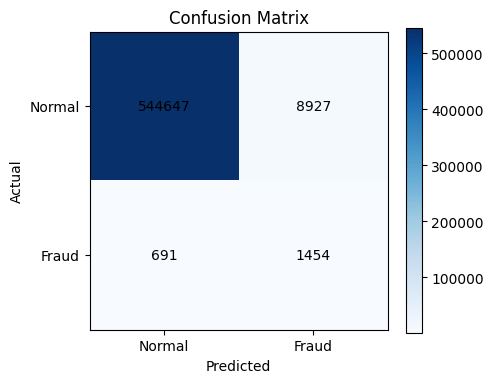

In [21]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")

for i in range(cm.shape[0]):
  for j in range(cm.shape[1]):
    ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Normal", "Fraud"])
ax.set_yticklabels(["Normal", "Fraud"])

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Normalized as %

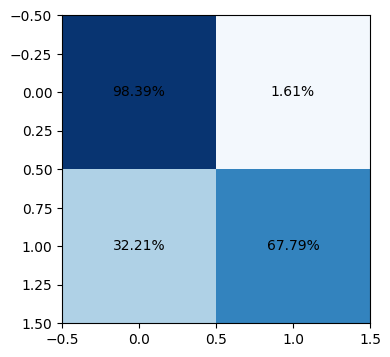

In [22]:
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)

for i in range(cm_normalized.shape[0]):
    for j in range(cm_normalized.shape[1]):
        ax.text(j, i, f"{cm_normalized[i, j]:.2%}", ha="center", va="center", color="black")

# Prediction

In [23]:
# Build one-row observation using existing feature schema
new_obs = df[input_features].iloc[[0]].copy()

new_obs.loc[:, "trans_date_trans_time"] = "12/2/2020 22:27"
new_obs.loc[:, "cc_num"] = 3.588e15
new_obs.loc[:, "merchant"] = "fraud_Torphy-Goyette"
new_obs.loc[:, "category"] = "shopping_pos"
new_obs.loc[:, "amt"] = 1318.89
new_obs.loc[:, "first"] = "Jason"
new_obs.loc[:, "last"] = "Johnson"
new_obs.loc[:, "gender"] = "M"
new_obs.loc[:, "street"] = "5942 Thomas Park"
new_obs.loc[:, "city"] = "Craig"
new_obs.loc[:, "state"] = "AK"
new_obs.loc[:, "zip"] = 99921
new_obs.loc[:, "lat"] = 55.4732
new_obs.loc[:, "long"] = -133.1171
new_obs.loc[:, "city_pop"] = 1920
new_obs.loc[:, "job"] = "Commissioning editor"
new_obs.loc[:, "unix_time"] = 1386023256
new_obs.loc[:, "merch_lat"] = 54.801713
new_obs.loc[:, "merch_long"] = -133.669108

# Apply same preprocessing pipeline
new_obs[string_cols] = enc.transform(new_obs[string_cols])
new_obs_scaled = scaler.transform(new_obs)

# Predict
pred_label = model.predict(new_obs_scaled)[0]
decision_score = model.decision_function(new_obs_scaled)[0]

print("Predicted is_fraud:", int(pred_label))
print("Decision score:", float(decision_score))
print("Actual is_fraud (provided):", 1)

Predicted is_fraud: 1
Decision score: 1.7866540196578802
Actual is_fraud (provided): 1
